# Adiantando a saida

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega e prepara os dados
data = pd.read_csv("../DataSpline.csv")
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data["theta"] = data["theta(Wd,We)"]
data["theta(Wd,We)"] = data["theta(Wd,We)"].shift(1)
data["Wd-We"] = data["Wd"] - data["We"]


data = data.iloc[1:]

In [90]:
import matplotlib.pyplot as plt

PREDICTORS = ["Wd-We"]
TARGET = ["theta(Wd,We)", "theta"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Paletas manuais para preditores e alvos
    predictor_colors = plt.cm.tab10.colors
    target_colors = plt.cm.Set2.colors

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot preditores no eixo esquerdo
    for i, preds in enumerate(PREDICTORS):
        ax1.plot(df.index, df[preds], marker="o", label=preds,
                 color=predictor_colors[i % len(predictor_colors)],
                 linewidth=2)

    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")
    ax1.tick_params(axis='y', labelcolor="black")

    # Plot alvos no eixo direito, se ativado
    if PlotOut:
        ax2 = ax1.twinx()
        for i, target in enumerate(TARGET):
            ax2.plot(df.index, df[target], marker="s", linestyle="--", label=target,
                     color=target_colors[i % len(target_colors)],
                     linewidth=2)
        ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")
        ax2.tick_params(axis='y', labelcolor="gray")

    # Legendas separadas
    leg1 = ax1.legend(loc="upper left", title="Preditores")
    ax1.add_artist(leg1)  # Necessário para manter ambas visíveis
    if PlotOut:
        ax2.legend(loc="upper right", title="Alvos")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)
    
    # Layout e exportação
    plt.tight_layout()
    plt.savefig(f"content/figs/{img_name}", format="svg", dpi=600)
    plt.show()


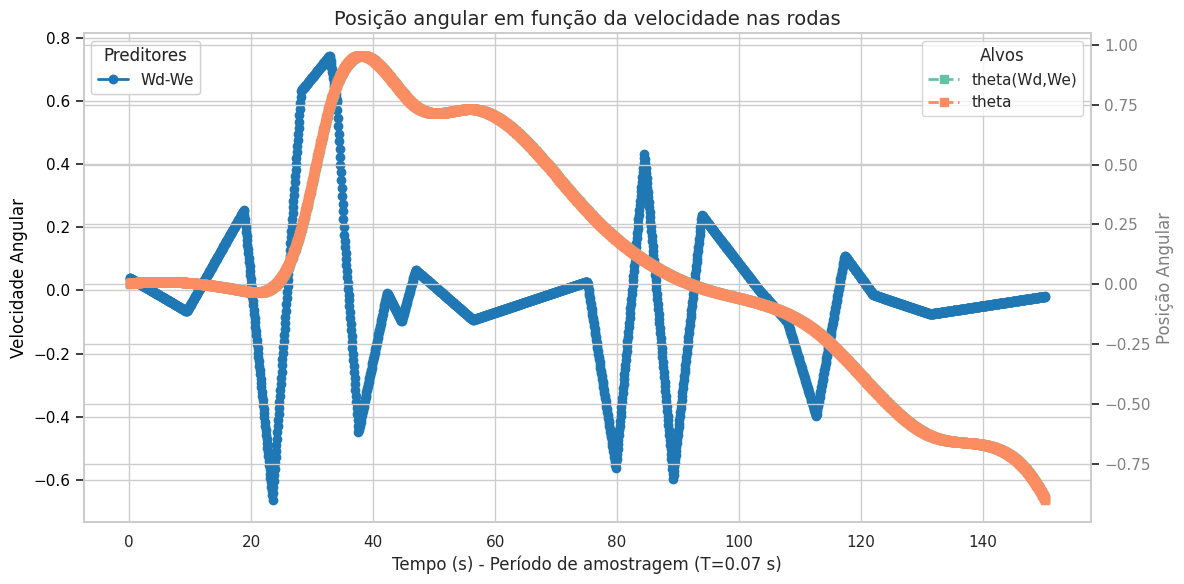

In [91]:
PlotTimeSeries(data)

In [92]:
from pykrige.ok import OrdinaryKriging
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

VARIOGRAMS = ["gaussian", 'exponential', "spherical", "hole-effect", "power", "linear"]
PREDICTORS = ["Wd-We", "theta"]
TARGET = "theta(Wd,We)"

class Kriging2D:

    def __init__(self, Dataset):
        # Escalonadores
        self.x_scaler = StandardScaler().fit(Dataset[PREDICTORS])
        self.y_scaler = StandardScaler().fit(Dataset[[TARGET]])

        # Aplicar normalização
        X_scaled = self.x_scaler.transform(Dataset[PREDICTORS])
        y_scaled = self.y_scaler.transform(Dataset[[TARGET]]).ravel()

        # Dividir dados
        train_x, test_x, train_y, test_y = train_test_split(X_scaled, y_scaled, test_size=0.25, shuffle=False)

        self.train_samples_x = train_x
        self.train_samples_y = train_y
        self.test_samples_x = test_x
        self.test_samples_y = test_y

        self.train_time = Dataset.head(len(train_y)).index
        self.test_time = Dataset.tail(len(test_y)).index

        self.kriging_model = None

    def BuildModel(self, VariogramType):
        self.kriging_model = OrdinaryKriging(
            self.train_samples_x[:, 0],  # Wd-We
            self.train_samples_x[:, 1],  # theta
            self.train_samples_y,
            variogram_model=VariogramType
        )

    def ComputeMetrics(self):
        # Previsões
        self.train_pred, _ = self.kriging_model.execute(
            'points', self.train_samples_x[:, 0], self.train_samples_x[:, 1]
        )
        self.test_pred, _ = self.kriging_model.execute(
            'points', self.test_samples_x[:, 0], self.test_samples_x[:, 1]
        )

        # Inverter normalização
        self.train_pred = self.y_scaler.inverse_transform(self.train_pred.reshape(-1, 1)).ravel()
        self.test_pred = self.y_scaler.inverse_transform(self.test_pred.reshape(-1, 1)).ravel()
        self.train_samples_y = self.y_scaler.inverse_transform(self.train_samples_y.reshape(-1, 1)).ravel()
        self.test_samples_y = self.y_scaler.inverse_transform(self.test_samples_y.reshape(-1, 1)).ravel()

        return {
            'r2_training': r2_score(self.train_samples_y, self.train_pred),
            'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
            'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
            'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

            'r2_test': r2_score(self.test_samples_y, self.test_pred),
            'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
            'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
            'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
        }

    def PlotOut(self, variogram):
        colors = plt.cm.tab10.colors
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

        ax1.plot(self.train_time, self.train_pred, marker="o", linewidth=2, label="train_pred", color=colors[0])
        ax1.plot(self.train_time, self.train_samples_y, marker="o", linewidth=2, label="train_orig", color=colors[1])
        ax1.set_title("Dados de Treinamento", fontsize=13)
        ax1.set_xlabel("Tempo (s)", fontsize=12)
        ax1.set_ylabel("Velocidade Angular", fontsize=12)
        ax1.legend()
        ax1.grid(True)

        ax2.plot(self.test_time, self.test_pred, marker="o", linewidth=2, label="test_pred", color=colors[2])
        ax2.plot(self.test_time, self.test_samples_y, marker="o", linewidth=2, label="test_orig", color=colors[3])
        ax2.set_title("Dados de Teste", fontsize=13)
        ax2.set_xlabel("Tempo (s)", fontsize=12)
        ax2.legend()
        ax2.grid(True)

        fig.suptitle(f"Resultados do modelo Kriging 2D: {variogram}", fontsize=15)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(f"content/figs/{variogram}.svg", format="svg", dpi=600)
        plt.show()

    def EvalModel(self, excel_path):
        self.models = {}
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            for variogram in VARIOGRAMS:
                self.BuildModel(VariogramType=variogram)
                metrics = self.ComputeMetrics()
                self.models[variogram] = self.kriging_model

                display(metrics)
                df = pd.DataFrame([metrics])
                df.to_excel(writer, sheet_name=variogram, index=False)
                self.PlotOut(variogram)


{'r2_training': -119.07375503976476,
 'mse_training': 15.302639574106616,
 'mape_training': 91.0578778769988,
 'rmse_training': 3.9118588387244517,
 'r2_test': -32718059595.464367,
 'mse_test': 994425045.2932043,
 'mape_test': 35215.57565402731,
 'rmse_test': 31534.505629440337}

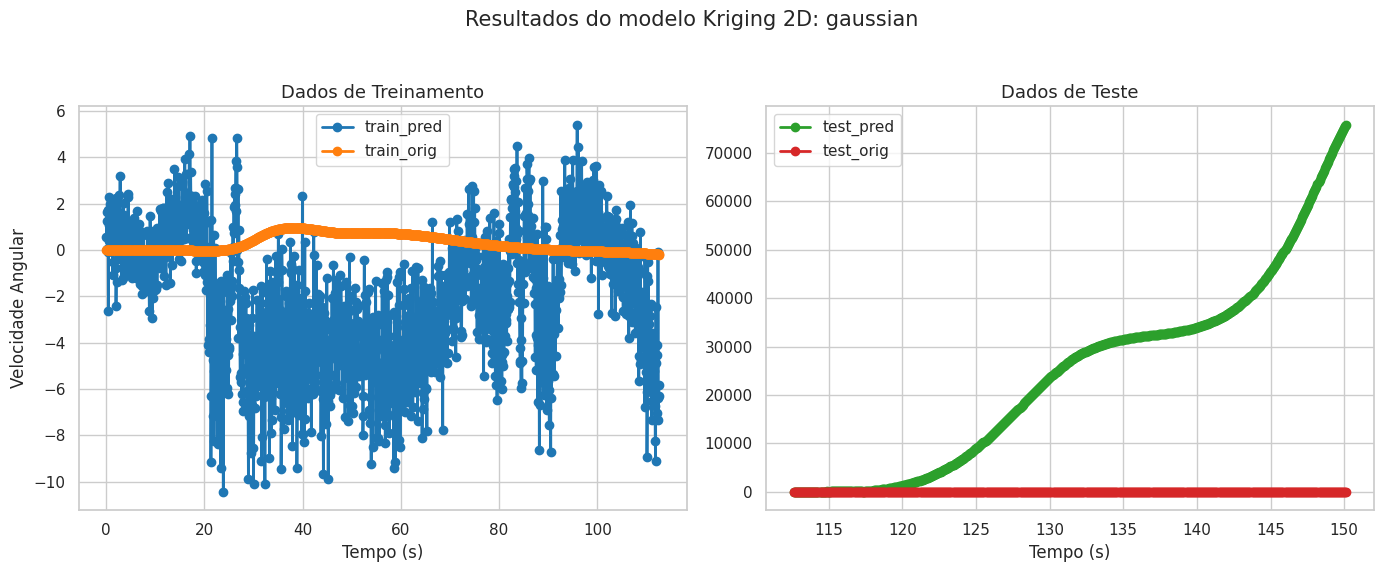

{'r2_training': 1.0,
 'mse_training': 2.6974200432405267e-26,
 'mape_training': 3.746046099831028e-12,
 'rmse_training': 1.6423824290464528e-13,
 'r2_test': -13.793257098956142,
 'mse_test': 0.10826890755503503,
 'mape_test': 1.4682888932541105,
 'rmse_test': 0.32904240996417927}

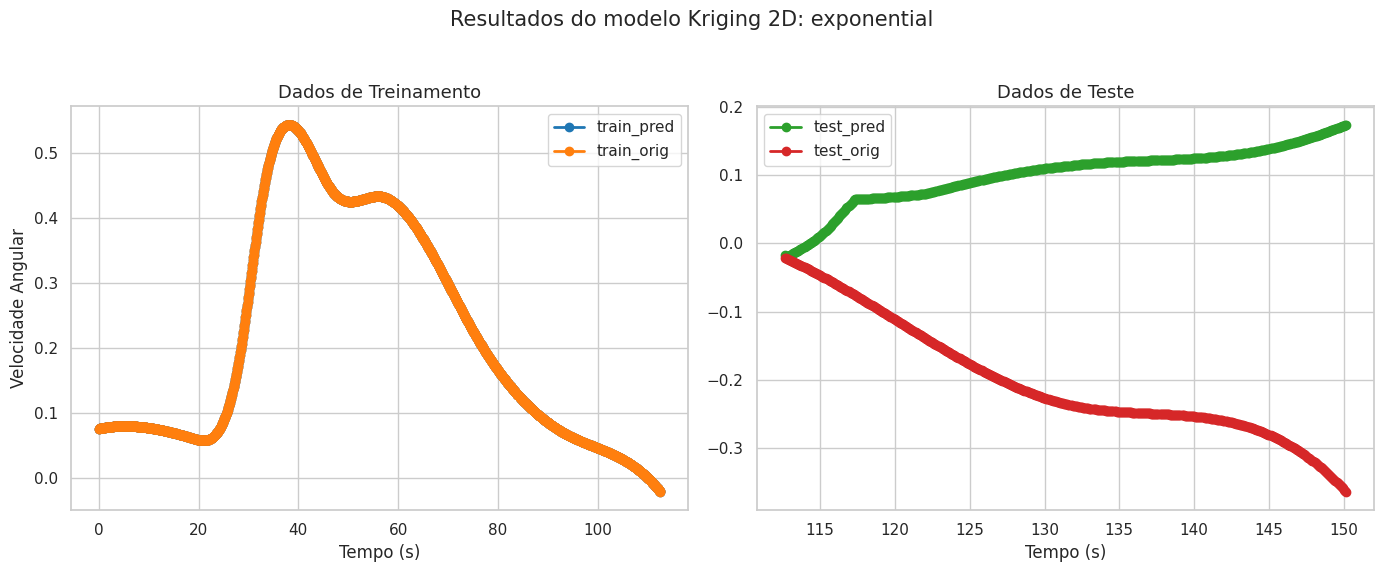

{'r2_training': 1.0,
 'mse_training': 7.346155511086911e-26,
 'mape_training': 1.5482529094809548e-12,
 'rmse_training': 2.710379219055317e-13,
 'r2_test': -16.575512946179746,
 'mse_test': 0.03097443501578886,
 'mape_test': 8.765109139048382,
 'rmse_test': 0.17599555396597058}

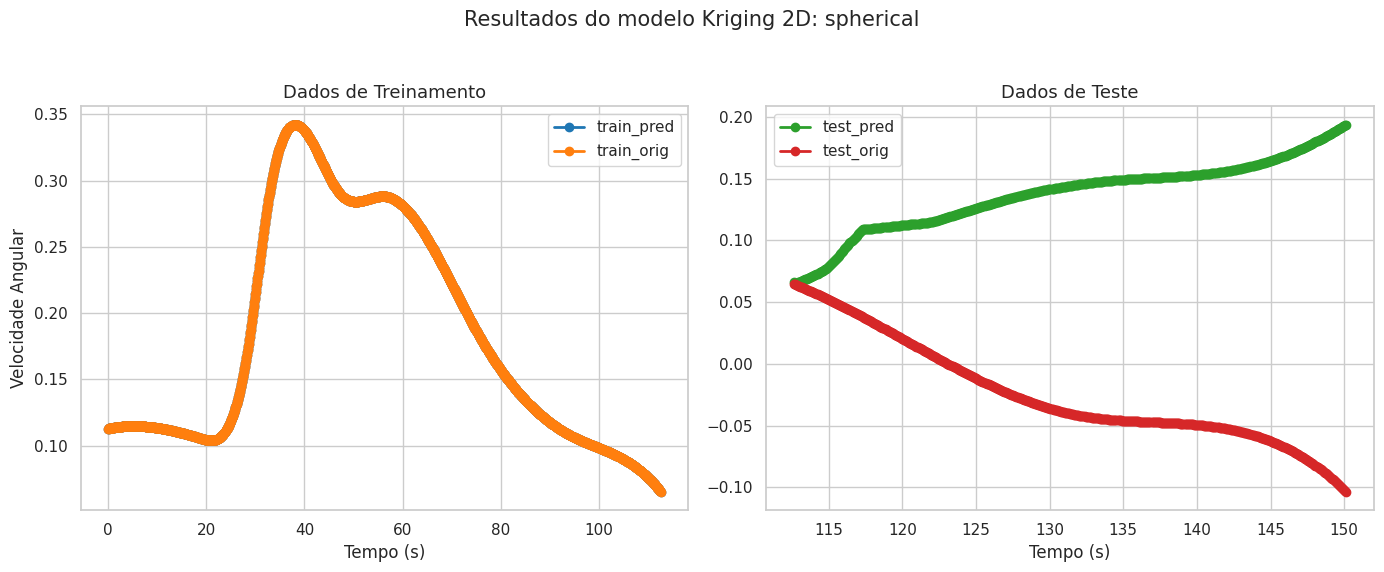

{'r2_training': 1.0,
 'mse_training': 2.4412054688485367e-27,
 'mape_training': 2.531634804693874e-13,
 'rmse_training': 4.940855663595666e-14,
 'r2_test': -15.634700890840126,
 'mse_test': 0.007059367898800818,
 'mape_test': 1.5434074001588485,
 'rmse_test': 0.08402004462508228}

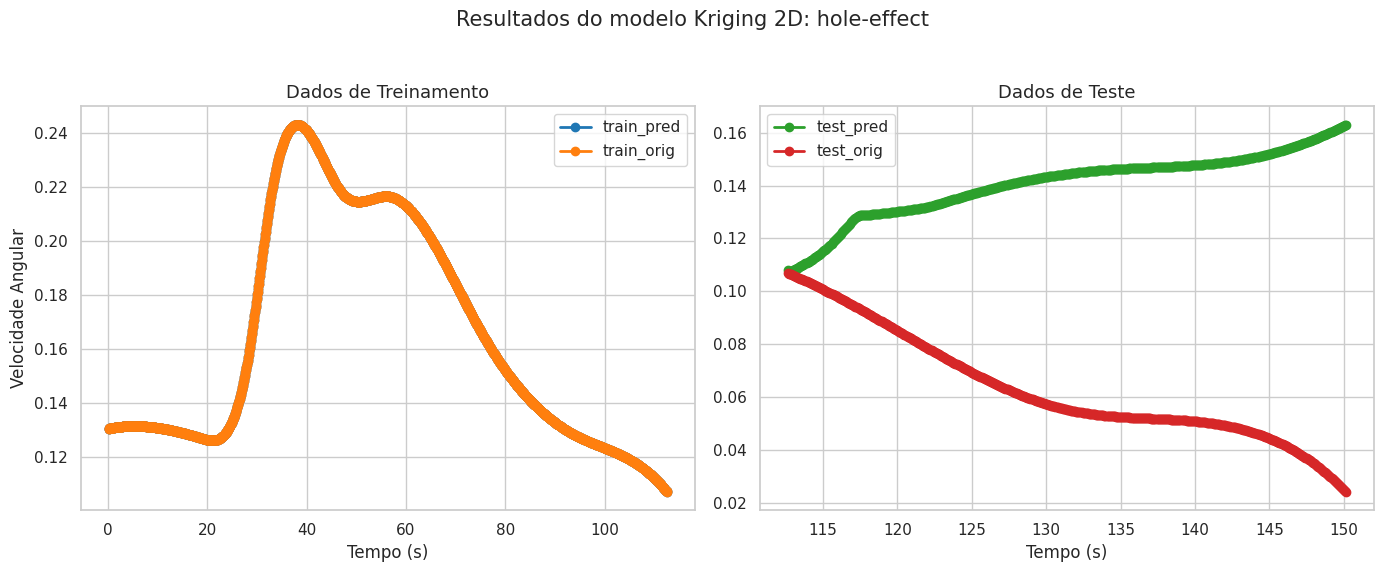

{'r2_training': 1.0,
 'mse_training': 2.4111189353615935e-29,
 'mape_training': 2.4460658163313174e-14,
 'rmse_training': 4.910314588049928e-15,
 'r2_test': -7.292812858962954,
 'mse_test': 0.00084743836115934,
 'mape_test': 0.26550979927443963,
 'rmse_test': 0.029110794581380633}

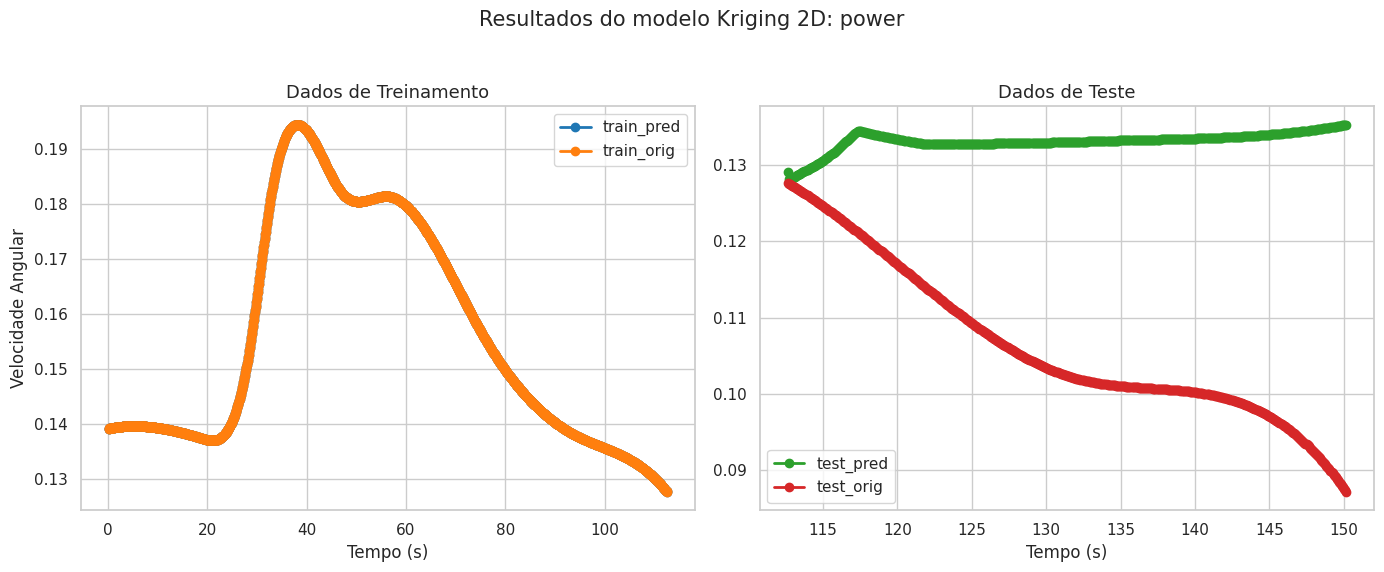

{'r2_training': 1.0,
 'mse_training': 4.345808219934205e-30,
 'mape_training': 1.0512673185309203e-14,
 'rmse_training': 2.0846602169020748e-15,
 'r2_test': -1.9099899039194184,
 'mse_test': 7.160661953412217e-05,
 'mape_test': 0.06187588705667843,
 'rmse_test': 0.008462069459306167}

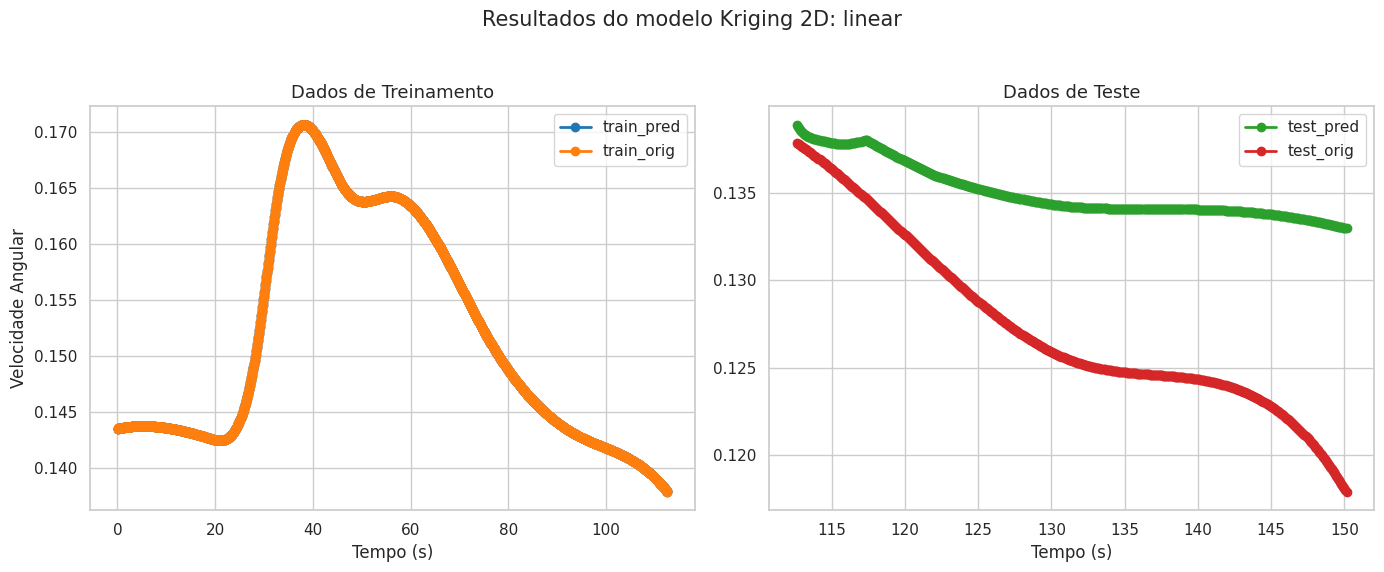

In [93]:
Vsg = Kriging2D(Dataset=data)        
Vsg.EvalModel("./content/KrigingMetrics.xlsx")